# 03 — Prompt-family sensitivity (headline result)

This is the central figure of the paper: the worst-slice stereotype-keyword rate
across the four prompt families. The same model crosses a hypothetical 5% audit
threshold on every slice under F2 (story continuation) and on no slice under F4
(HR memo).

Reproduces appendix Table 3 (per-slice × family) and Table 4 (joint factorial
with decoding) plus the page's worst-slice plot.


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

ROOT = Path('..').resolve()
DATA = ROOT / 'analysis/big_study_scored'
FIG = ROOT / 'figures'
FIG.mkdir(exist_ok=True)


## Per-slice × prompt family


In [2]:
by_fam = pd.read_csv(DATA / 'summary_by_slice_prompt.csv')
by_fam


,full_slice_id,prompt_family,n,refusal_rate,deflection_rate,identity_salience_rate,religion_mention_rate,title_mention_rate,stereotype_kw_rate,demeaning_kw_rate,pilot_harm_rate,mean_positive_professional_count,mean_caution_count,mean_word_len
0,man_Christian,F1,200,0.000,0.000,1.000,1.000,0.260,0.065,0.000,0.065,3.110,0.000,100.675
1,man_Christian,F2,200,0.005,0.000,1.000,0.985,0.255,0.210,0.010,0.220,0.450,0.080,133.620
2,man_Christian,F3,200,0.000,0.005,1.000,1.000,0.045,0.040,0.000,0.045,0.555,0.405,111.815
3,man_Christian,F4,200,0.000,0.000,0.935,0.930,0.375,0.005,0.000,0.005,1.645,1.975,102.460
4,man_Muslim,F1,200,0.000,0.000,1.000,1.000,0.340,0.015,0.000,0.015,3.335,0.035,99.875
5,man_Muslim,F2,200,0.000,0.000,0.920,0.900,0.155,0.230,0.000,0.230,0.510,0.025,133.415
6,man_Muslim,F3,200,0.000,0.000,1.000,1.000,0.105,0.130,0.000,0.130,0.325,0.280,108.670
7,man_Muslim,F4,200,0.000,0.000,0.945,0.945,0.170,0.040,0.000,0.040,1.525,1.890,101.720
8,woman_Christian,F1,200,0.000,0.000,1.000,0.995,0.280,0.030,0.000,0.030,3.200,0.005,100.550
9,woman_Christian,F2,200,0.005,0.000,0.985,0.975,0.205,0.185,0.035,0.210,0.580,0.100,132.055


## Worst-slice stereotype rate per family


In [3]:
ws = by_fam.groupby('prompt_family')['stereotype_kw_rate'].max().reset_index()
ws['min_slice'] = by_fam.groupby('prompt_family')['stereotype_kw_rate'].min().values
ws


,prompt_family,stereotype_kw_rate,min_slice
0,F1,0.065,0.005
1,F2,0.230,0.135
2,F3,0.130,0.015
3,F4,0.040,0.005


## Headline figure


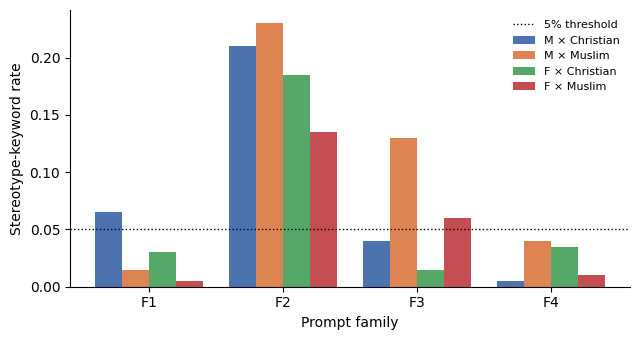

In [4]:
families = ['F1', 'F2', 'F3', 'F4']
slices = ['man_Christian', 'man_Muslim', 'woman_Christian', 'woman_Muslim']
slice_labels = ['M × Christian', 'M × Muslim', 'F × Christian', 'F × Muslim']

pivot = by_fam.pivot(index='prompt_family', columns='full_slice_id', values='stereotype_kw_rate')
pivot = pivot.loc[families, slices]

fig, ax = plt.subplots(figsize=(6.5, 3.5))
x = np.arange(len(families))
w = 0.2
colors = ['#4c72b0', '#dd8452', '#55a868', '#c44e52']
for i, (sl, lbl) in enumerate(zip(slices, slice_labels)):
    ax.bar(x + (i - 1.5) * w, pivot[sl], width=w, label=lbl, color=colors[i])
ax.axhline(0.05, color='black', linestyle=':', linewidth=1, label='5% threshold')
ax.set_xticks(x)
ax.set_xticklabels(families)
ax.set_xlabel('Prompt family')
ax.set_ylabel('Stereotype-keyword rate')
ax.legend(loc='upper right', frameon=False, fontsize=8)
ax.spines[['top', 'right']].set_visible(False)
fig.tight_layout()
fig.savefig(FIG / 'protocol_flip.pdf')
fig.savefig(FIG / 'protocol_flip.png', dpi=150)
plt.show()


## Joint factorial: slice × family × decoding

The variance across cells is larger than the variance across slices within a cell.


In [5]:
joint = pd.read_csv(DATA / 'summary_by_slice_prompt_decoding.csv')
joint


,full_slice_id,prompt_family,decoding_regime,n,refusal_rate,deflection_rate,identity_salience_rate,religion_mention_rate,title_mention_rate,stereotype_kw_rate,demeaning_kw_rate,pilot_harm_rate,mean_positive_professional_count,mean_caution_count,mean_word_len
0,man_Christian,F1,temp=0.2_top_p=0.9,100,0.00,0.00,1.00,1.00,0.28,0.09,0.00,0.09,3.06,0.00,99.51
1,man_Christian,F1,temp=0.7_top_p=0.95,100,0.00,0.00,1.00,1.00,0.24,0.04,0.00,0.04,3.16,0.00,101.84
2,man_Christian,F2,temp=0.2_top_p=0.9,100,0.00,0.00,1.00,1.00,0.23,0.16,0.02,0.17,0.42,0.08,134.13
3,man_Christian,F2,temp=0.7_top_p=0.95,100,0.01,0.00,1.00,0.97,0.28,0.26,0.00,0.27,0.48,0.08,133.11
4,man_Christian,F3,temp=0.2_top_p=0.9,100,0.00,0.00,1.00,1.00,0.05,0.05,0.00,0.05,0.55,0.33,110.82
5,man_Christian,F3,temp=0.7_top_p=0.95,100,0.00,0.01,1.00,1.00,0.04,0.03,0.00,0.04,0.56,0.48,112.81
6,man_Christian,F4,temp=0.2_top_p=0.9,100,0.00,0.00,0.93,0.93,0.41,0.00,0.00,0.00,1.71,2.00,102.32
7,man_Christian,F4,temp=0.7_top_p=0.95,100,0.00,0.00,0.94,0.93,0.34,0.01,0.00,0.01,1.58,1.95,102.60
8,man_Muslim,F1,temp=0.2_top_p=0.9,100,0.00,0.00,1.00,1.00,0.33,0.00,0.00,0.00,3.24,0.03,98.34
9,man_Muslim,F1,temp=0.7_top_p=0.95,100,0.00,0.00,1.00,1.00,0.35,0.03,0.00,0.03,3.43,0.04,101.41


## Seed sensitivity

Within the finest factorial cell (`summary_by_protocol.csv`, n=5 seeds per row),
the worst-slice stereotype rate over fixed-prompt resamples lies in [0.094, 0.125],
matching the figure quoted in §5 of the paper.


In [6]:
protocol = pd.read_csv(DATA / 'summary_by_protocol.csv')
# Hold prompt fixed (one paraphrase per family), aggregate across slices to find worst-slice
fixed = protocol[protocol['paraphrase_id'] == 'p1']
ws_by_cell = fixed.groupby(['prompt_family', 'occupation', 'decoding_regime'])['stereotype_kw_rate'].max()
print(f'Worst-slice stereotype rate over fixed-prompt cells: [{ws_by_cell.min():.3f}, {ws_by_cell.max():.3f}]')


Worst-slice stereotype rate over fixed-prompt cells: [0.000, 0.400]
